In [1]:
import pandas as pd
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [ ]:
full = pd.read_csv('../Myun_EDA/preprocessed_final.csv')

In [4]:
import pandas as pd
import numpy as np

# 1) 이벤트별 추출
received = (
    full.loc[full['event'] == 'offer received', ['person', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_received'})
    .sort_values(['person', 'offer_id', 't_received'])
    .reset_index(drop=True)
)

viewed = (
    full.loc[full['event'] == 'offer viewed', ['person', 'offer_id', 'time','offer_type']]
    .rename(columns={'time': 't_viewed'})
    .sort_values(['person', 'offer_id', 't_viewed'])
    .reset_index(drop=True)
)

completed = (
    full.loc[full['event'] == 'offer completed', ['person', 'offer_id', 'time','offer_type']]
    .rename(columns={'time': 't_completed'})
    .sort_values(['person', 'offer_id', 't_completed'])
    .reset_index(drop=True)
)

# 2) received 인스턴스 번호 부여
received['instance_id'] = (
    received.groupby(['person', 'offer_id'])
    .cumcount() + 1
)

# merge_asof를 위해 정렬
received_asof = received.sort_values(['t_received', 'person', 'offer_id']).reset_index(drop=True)
viewed_asof = viewed.sort_values(['t_viewed', 'person', 'offer_id']).reset_index(drop=True)
completed_asof = completed.sort_values(['t_completed', 'person', 'offer_id']).reset_index(drop=True)

# 3) 각 viewed를 "가장 가까운 직전 received 인스턴스"에 연결
view_map = pd.merge_asof(
    viewed_asof,
    received_asof[['person', 'offer_id', 't_received', 'instance_id']],
    left_on='t_viewed',
    right_on='t_received',
    by=['person', 'offer_id'],
    direction='backward',
    allow_exact_matches=True
)

# 4) 각 completed도 "가장 가까운 직전 received 인스턴스"에 연결
comp_map = pd.merge_asof(
    completed_asof,
    received_asof[['person', 'offer_id', 't_received', 'instance_id']],
    left_on='t_completed',
    right_on='t_received',
    by=['person', 'offer_id'],
    direction='backward',
    allow_exact_matches=True
)

# 5) 혹시 received 이전 이벤트가 잘못 붙은 경우 제거 (보통 없어야 정상)
view_map = view_map[view_map['instance_id'].notna()].copy()
comp_map = comp_map[comp_map['instance_id'].notna()].copy()

# 6) 인스턴스별 첫 viewed / 첫 completed만 남기기
view_summary = (
    view_map.groupby(['person', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_viewed=('t_viewed', 'min'),
        last_viewed=('t_viewed', 'max'),
        view_count=('t_viewed', 'count')
    )
)

comp_summary = (
    comp_map.groupby(['person', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_completed=('t_completed', 'min'),
        last_completed=('t_completed', 'max'),
        complete_count=('t_completed', 'count')
    )
)
funnel_instance = (
    received.merge(view_summary, on=['person', 'offer_id', 'instance_id'], how='left')
            .merge(comp_summary, on=['person', 'offer_id', 'instance_id'], how='left')
)

# 8) 시간 간격 계산
# 인스턴스 기준 시간차
funnel_instance['gap_to_first_view'] = funnel_instance['first_viewed'] - funnel_instance['t_received']
funnel_instance['gap_to_first_complete'] = funnel_instance['first_completed'] - funnel_instance['t_received']
funnel_instance['gap_first_view_to_first_complete'] = funnel_instance['first_completed'] - funnel_instance['first_viewed']

# day 단위
funnel_instance['gap_to_first_view_day'] = funnel_instance['gap_to_first_view'] / 24
funnel_instance['gap_to_first_complete_day'] = funnel_instance['gap_to_first_complete'] / 24
funnel_instance['gap_first_view_to_first_complete_day'] = funnel_instance['gap_first_view_to_first_complete'] / 24

# 9) 품질 체크용 플래그
funnel_instance['is_viewed'] = funnel_instance['first_viewed'].notna()
funnel_instance['is_completed'] = funnel_instance['first_completed'].notna()
funnel_instance['completed_without_view'] = (
    funnel_instance['first_completed'].notna() & funnel_instance['first_viewed'].isna()
)

# 10) 출력
print(f"\n전체 오퍼 received 인스턴스 수: {len(funnel_instance):,}건")

print("\n[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]")
v = funnel_instance['gap_to_first_view'].dropna()
print(f"  평균   : {v.mean():.1f}시간 ({v.mean()/24:.1f}일)")
print(f"  중앙값 : {v.median():.1f}시간 ({v.median()/24:.1f}일)")
print(f"  6시간 내 열람 : {(v <= 6).mean()*100:.1f}%")
print(f"  24시간 내 열람: {(v <= 24).mean()*100:.1f}%")
print(f"  48시간 내 열람: {(v <= 48).mean()*100:.1f}%")

print("\n[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]")
c = funnel_instance['gap_to_first_complete'].dropna()
print(f"  평균   : {c.mean():.1f}시간 ({c.mean()/24:.1f}일)")
print(f"  중앙값 : {c.median():.1f}시간 ({c.median()/24:.1f}일)")
print(f"  1일 내 완료: {(c <= 24).mean()*100:.1f}%")
print(f"  3일 내 완료: {(c <= 72).mean()*100:.1f}%")
print(f"  7일 내 완료: {(c <= 168).mean()*100:.1f}%")

print("\n[ 퍼널 요약 ]")
print(f"  Viewed rate     : {funnel_instance['is_viewed'].mean()*100:.1f}%")
print(f"  Completed rate  : {funnel_instance['is_completed'].mean()*100:.1f}%")
print(f"  완료했지만 미열람: {funnel_instance['completed_without_view'].mean()*100:.1f}%")


전체 오퍼 received 인스턴스 수: 76,277건

[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]
  평균   : 26.7시간 (1.1일)
  중앙값 : 18.0시간 (0.8일)
  6시간 내 열람 : 37.7%
  24시간 내 열람: 66.0%
  48시간 내 열람: 83.5%

[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]
  평균   : 61.2시간 (2.5일)
  중앙값 : 48.0시간 (2.0일)
  1일 내 완료: 31.2%
  3일 내 완료: 66.8%
  7일 내 완료: 96.7%

[ 퍼널 요약 ]
  Viewed rate     : 75.7%
  Completed rate  : 43.4%
  완료했지만 미열람: 7.4%


In [5]:
funnel_instance.head()

,person,offer_id,t_received,offer_type,instance_id,first_viewed,last_viewed,view_count,first_completed,last_completed,complete_count,gap_to_first_view,gap_to_first_complete,gap_first_view_to_first_complete,gap_to_first_view_day,gap_to_first_complete_day,gap_first_view_to_first_complete_day,is_viewed,is_completed,completed_without_view
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,NaN,NaN,NaN,576.0,576.0,1.0,NaN,0.0,NaN,NaN,0.00,NaN,False,True,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,372.0,372.0,1.0,NaN,NaN,NaN,36.0,NaN,NaN,1.5,NaN,NaN,True,False,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,192.0,192.0,1.0,NaN,NaN,NaN,24.0,NaN,NaN,1.0,NaN,NaN,True,False,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,456.0,456.0,1.0,414.0,414.0,1.0,48.0,6.0,-42.0,2.0,0.25,-1.75,True,True,False
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,540.0,540.0,1.0,528.0,528.0,1.0,36.0,24.0,-12.0,1.5,1.00,-0.50,True,True,False


In [6]:
print("received 원건수:", len(received))
print("instance funnel 원건수:", len(funnel_instance))

received 원건수: 76277
instance funnel 원건수: 76277


In [8]:
print("Viewed rate:", funnel_instance['is_viewed'].mean())
print("Completed rate:", funnel_instance['is_completed'].mean())
print("Completed without view:", (
    funnel_instance['is_completed'] & ~funnel_instance['is_viewed']
).mean())
#오퍼 노출은 잘 된다
#전환에서 크게 떨어진다
#사용자가 오퍼를 안 보고도
#조건을 충족해서 reward를 받음

Viewed rate: 0.7567812053436815
Completed rate: 0.4339578116601335
Completed without view: 0.07379681948687022


In [20]:
print((funnel_instance['gap_to_view'] < 0).sum())
print((funnel_instance['gap_to_complete'] < 0).sum())
print((funnel_instance['gap_view_to_complete'] < 0).sum())
#completed < viewed
#완료가 열람보다 먼저 발생 -> viewed 없이도 completion 가능

0
0
4205


In [9]:
funnel_instance[['person','offer_id','instance_id']].duplicated().sum()

np.int64(0)

In [10]:
funnel_instance['valid_view_sequence'] = (
    funnel_instance['first_viewed'].notna() &
    funnel_instance['first_completed'].notna() &
    (funnel_instance['first_viewed'] <= funnel_instance['first_completed'])
)

In [11]:
funnel_instance.groupby('offer_type')[['is_viewed', 'is_completed']].mean()

,is_viewed,is_completed
offer_type,,
bogo,0.834421,0.508246
discount,0.702125,0.576237
informational,0.710929,0.000000


In [12]:
funnel_instance.groupby('offer_type')['gap_to_first_complete'].median()

offer_type
bogo             42.0
discount         60.0
informational     NaN
Name: gap_to_first_complete, dtype: float64

In [13]:
# -------------------------------
# 분석 2. duration 내 반응 여부 
# -------------------------------

print("=" * 50)
print("[유효기간(duration) 내 완료율 ]")
print("=" * 50)

# 1. portfolio 정보 준비
portfolio = (
    full[['offer_id', 'duration', 'offer_type']]
    .dropna(subset=['offer_id', 'duration'])
    .drop_duplicates('offer_id')
    .rename(columns={
        'duration': 'offer_duration',
        'offer_type': 'offer_type_port'
    })
)

# 2. 기존 관련 컬럼 제거 후 다시 병합
funnel_instance = funnel_instance.drop(
    columns=['offer_duration', 'offer_type_port', 'duration_hours', 'within_duration'],
    errors='ignore'
)

funnel_instance = funnel_instance.merge(
    portfolio,
    on='offer_id',
    how='left'
)

# 3. 유효기간 계산
funnel_instance['duration_hours'] = funnel_instance['offer_duration'] * 24

funnel_instance['within_duration'] = (
    funnel_instance['gap_to_first_complete'].notna() &
    (funnel_instance['gap_to_first_complete'] <= funnel_instance['duration_hours'])
)

# 4. 완료 인스턴스만 다시 생성
completed_funnel_instance = funnel_instance[
    funnel_instance['is_completed']
].copy()

print(f"\n완료 인스턴스 수: {len(completed_funnel_instance):,}건")
print(
    f"유효기간 내 완료: {completed_funnel_instance['within_duration'].sum():,}건 "
    f"({completed_funnel_instance['within_duration'].mean()*100:.1f}%)"
)
print(
    f"유효기간 초과 완료: {(~completed_funnel_instance['within_duration']).sum():,}건 "
    f"({(~completed_funnel_instance['within_duration']).mean()*100:.1f}%)"
)

print("\n[ duration별 유효기간 내 완료율 ]")
dur_rate = completed_funnel_instance.groupby('offer_duration')['within_duration'].agg(['sum', 'count', 'mean'])
dur_rate.columns = ['유효기간 내 완료', '전체 완료', '완료율']
dur_rate['완료율'] = dur_rate['완료율'].map(lambda x: f"{x*100:.1f}%")
print(dur_rate)

print("\n[ 오퍼 유형별 평균 반응 시간 ]")
for otype in ['bogo', 'discount']:
    df = completed_funnel_instance.loc[
        completed_funnel_instance['offer_type_port'] == otype,
        'gap_to_first_complete'
    ]
    print(f"  {otype:<12} 평균 {df.mean()/24:.1f}일  중앙값 {df.median()/24:.1f}일")

[유효기간(duration) 내 완료율 ]

완료 인스턴스 수: 33,101건
유효기간 내 완료: 33,101건 (100.0%)
유효기간 초과 완료: 0건 (0.0%)

[ duration별 유효기간 내 완료율 ]
                유효기간 내 완료  전체 완료     완료율
offer_duration                          
5.0                  7563   7563  100.0%
7.0                 16995  16995  100.0%
10.0                 8543   8543  100.0%

[ 오퍼 유형별 평균 반응 시간 ]
  bogo         평균 2.1일  중앙값 1.8일
  discount     평균 3.0일  중앙값 2.5일


In [ ]:
funnel_instance['was_viewed'] = funnel_instance['first_viewed'].notna().astype(int)
funnel_instance['was_completed'] = funnel_instance['first_completed'].notna().astype(int)

funnel_instance['completed_without_view'] = (
    (funnel_instance['was_completed'] == 1) &
    (funnel_instance['was_viewed'] == 0)
).astype(int)

funnel_instance['valid_view_sequence'] = (
    funnel_instance['first_viewed'].notna() &
    funnel_instance['first_completed'].notna() &
    (funnel_instance['first_viewed'] <= funnel_instance['first_completed'])
).astype(int)

funnel_instance.to_csv('../Soyun_EDA/funnel_instance.csv', index=False)

In [15]:
# ============================================================
# 분석 3. 자연 거래 패턴
# ============================================================
print("=" * 50)
print("[자연 거래 패턴]")
print("=" * 50)

# 1) offer_id별 duration 정보
portfolio_dur = (
    full[['offer_id', 'duration']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)

# 2) received 이벤트에 duration 붙여서 활성 구간 생성
received_with_dur = received.merge(portfolio_dur, on='offer_id', how='left')
received_with_dur['t_expire'] = received_with_dur['t_received'] + received_with_dur['duration'] * 24

# 3) transaction만 추출
tx = full[full['event'] == 'transaction'][[
    'person', 'time', 'amount',
    'income_group', 'age_group', 'age_gender',
    'join_year', 'join_month', 'join_year_month', 'join_cohort'
]].copy().reset_index(drop=True)

print("자연 거래 분류 중... (벡터화 방식)")

# 4) transaction 시점에 같은 person의 활성 오퍼가 있었는지 확인
recv = received_with_dur[['person', 't_received', 't_expire']].copy()

tx_recv = tx.merge(recv, on='person', how='left')

tx_recv['is_active'] = (
    (tx_recv['t_received'] <= tx_recv['time']) &
    (tx_recv['t_expire'] >= tx_recv['time'])
)

# person + time 기준으로 "활성 오퍼가 하나라도 있었는지" 집계
active_flag = (
    tx_recv.groupby(['person', 'time'])['is_active']
    .any()
    .reset_index()
    .rename(columns={'is_active': 'has_active_offer'})
)

# 5) transaction 테이블에 다시 붙이기
tx = tx.merge(active_flag, on=['person', 'time'], how='left')
tx['has_active_offer'] = tx['has_active_offer'].fillna(False)
tx['is_natural'] = ~tx['has_active_offer']

# 6) 분리
nat_tx = tx[tx['is_natural']].copy()
act_tx = tx[~tx['is_natural']].copy()

# 7) 기본 요약
print(f"\n전체 transaction 수       : {len(tx):,}건")
print(f"자연 거래 (오퍼 없음)     : {len(nat_tx):,}건 ({len(nat_tx)/len(tx)*100:.1f}%)")
print(f"오퍼 활성 중 거래         : {len(act_tx):,}건 ({len(act_tx)/len(tx)*100:.1f}%)")

print("\n[ 자연 거래 vs 오퍼 중 거래 평균 금액 ]")
print(f"  자연 거래 평균     : ${nat_tx['amount'].mean():.2f}")
print(f"  오퍼 중 거래 평균  : ${act_tx['amount'].mean():.2f}")
print(f"  차이 (오퍼-자연)   : ${act_tx['amount'].mean() - nat_tx['amount'].mean():.2f}")

# 8) 분포 출력용 함수
def print_dist(df, col, title, order=None):
    print(f"\n[ {title} ]")
    if order is None:
        vc = df[col].value_counts(dropna=False)
        for v, c in vc.items():
            print(f"  {str(v):<15} {c:>6,}건 ({c/len(df)*100:.1f}%)")
    else:
        for v in order:
            c = (df[col] == v).sum()
            print(f"  {str(v):<15} {c:>6,}건 ({c/len(df)*100:.1f}%)")

# 9) 자연 거래 고객 특성 분포
inc_order = ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']
age_order = ['누락', '20대 미만', '20대', '30대', '40대', '50대', '60대 이상']

age_gender_order = ['미기입', 'Others']
age_bins = ['20세 미만', '20대', '30대', '40대', '50대', '60대', '60+']
genders = ['남성', '여성']
for g in genders:
    for a in age_bins:
        age_gender_order.append(f"{a} {g}")

print_dist(nat_tx, 'income_group', '자연 거래 소득 구간 분포', inc_order)
print_dist(nat_tx, 'age_group', '자연 거래 연령대 분포', age_order)
print_dist(nat_tx, 'age_gender', '자연 거래 연령×성별 분포', age_gender_order)

# 10) 자연 거래 비율 (세그먼트별)
print("\n[ 세그먼트별 자연 거래 비율 ]")

nat_rate_income = tx.groupby('income_group')['is_natural'].mean().reindex(inc_order)
print("\n소득 구간별 자연 거래 비율")
for idx, val in nat_rate_income.items():
    print(f"  {idx:<15} {val*100:>5.1f}%")

nat_rate_age = tx.groupby('age_group')['is_natural'].mean().reindex(age_order)
print("\n연령대별 자연 거래 비율")
for idx, val in nat_rate_age.items():
    print(f"  {idx:<15} {val*100:>5.1f}%")

nat_rate_join = tx.groupby('join_year')['is_natural'].mean().sort_index()
print("\n가입 연도별 자연 거래 비율")
for idx, val in nat_rate_join.items():
    print(f"  {str(idx):<15} {val*100:>5.1f}%")

# 11) 고객 단위 자연 거래 성향
customer_nat_ratio = (
    tx.groupby('person')['is_natural']
    .mean()
    .reset_index(name='natural_tx_ratio')
)

print("\n[ 고객 단위 자연 거래 비율 ]")
print(customer_nat_ratio['natural_tx_ratio'].describe())

# 12) 필요시 저장
# tx.to_csv('../Soyun_EDA/transaction_natural_flag.csv', index=False)
# customer_nat_ratio.to_csv('../Soyun_EDA/customer_natural_ratio.csv', index=False)

[자연 거래 패턴]
자연 거래 분류 중... (벡터화 방식)

전체 transaction 수       : 138,953건
자연 거래 (오퍼 없음)     : 17,090건 (12.3%)
오퍼 활성 중 거래         : 121,863건 (87.7%)

[ 자연 거래 vs 오퍼 중 거래 평균 금액 ]
  자연 거래 평균     : $12.76
  오퍼 중 거래 평균  : $12.78
  차이 (오퍼-자연)   : $0.02

[ 자연 거래 소득 구간 분포 ]
  누락               1,994건 (11.7%)
  5만 미만            4,446건 (26.0%)
  5-7.5만           6,923건 (40.5%)
  7.5-10만          2,910건 (17.0%)
  10만 이상             817건 (4.8%)

[ 자연 거래 연령대 분포 ]
  누락               1,994건 (11.7%)
  20대 미만             246건 (1.4%)
  20대              1,565건 (9.2%)
  30대              1,746건 (10.2%)
  40대              2,418건 (14.1%)
  50대              3,451건 (20.2%)
  60대 이상           5,670건 (33.2%)

[ 자연 거래 연령×성별 분포 ]
  미기입              1,994건 (11.7%)
  Others             230건 (1.3%)
  20세 미만 남성          190건 (1.1%)
  20대 남성           1,070건 (6.3%)
  30대 남성           1,129건 (6.6%)
  40대 남성           1,520건 (8.9%)
  50대 남성           1,973건 (11.5%)
  60대 남성           1,573건 (9.2%)
  60+ 남성           1,397건 (8.2

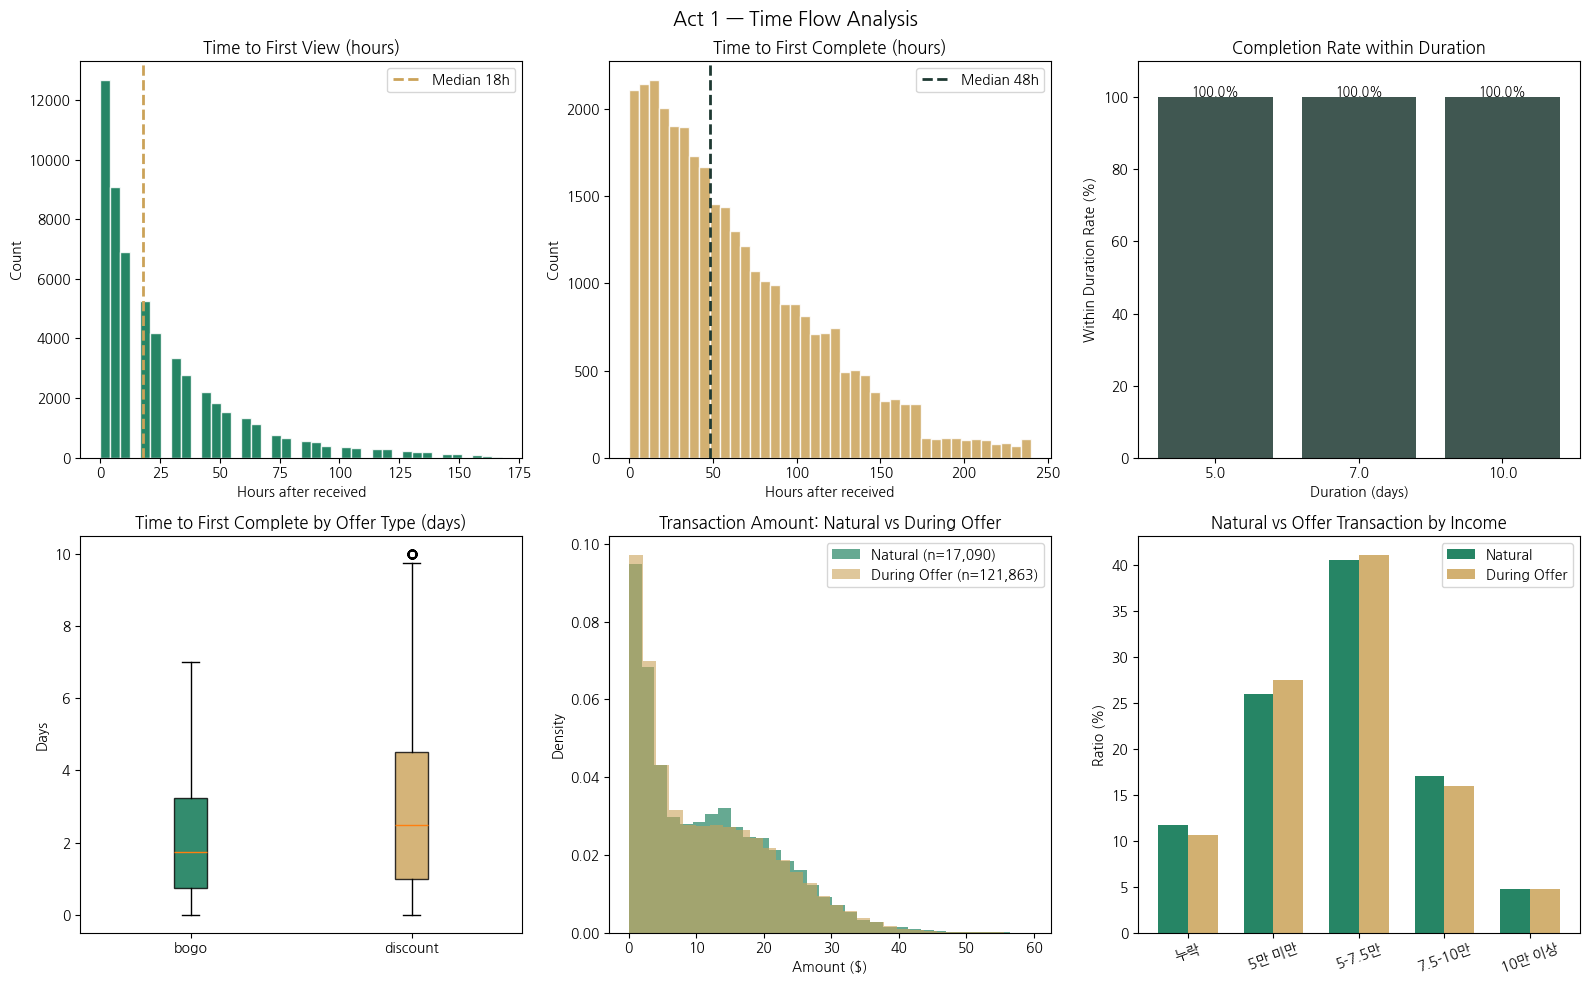

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Act 1 — Time Flow Analysis', fontsize=14, fontweight='bold')

# ⭐ 스타벅스 컬러
green = '#00704A'
gold = '#CBA258'
dark = '#1E3932'
light = '#D4E9E2'
deep = '#006241'

# 차트 1: 수신 → 첫 열람 시간 분포
ax1 = axes[0, 0]
v_plot = funnel_instance['gap_to_first_view'].dropna()
v_plot = v_plot[v_plot <= 168]

ax1.hist(v_plot, bins=40, color=green, alpha=0.85, edgecolor='white')
ax1.axvline(v_plot.median(), color=gold, linestyle='--', linewidth=2,
            label=f'Median {v_plot.median():.0f}h')

ax1.set_title('Time to First View (hours)', fontweight='bold')
ax1.set_xlabel('Hours after received')
ax1.set_ylabel('Count')
ax1.legend()

# 차트 2: 수신 → 첫 완료 시간 분포
ax2 = axes[0, 1]
c_plot = funnel_instance['gap_to_first_complete'].dropna()
c_plot = c_plot[c_plot <= 240]

ax2.hist(c_plot, bins=40, color=gold, alpha=0.85, edgecolor='white')
ax2.axvline(c_plot.median(), color=dark, linestyle='--', linewidth=2,
            label=f'Median {c_plot.median():.0f}h')

ax2.set_title('Time to First Complete (hours)', fontweight='bold')
ax2.set_xlabel('Hours after received')
ax2.set_ylabel('Count')
ax2.legend()

# 차트 3: duration별 완료율
ax3 = axes[0, 2]
dur_data = completed_funnel_instance.groupby('offer_duration')['within_duration'].mean() * 100

ax3.bar(dur_data.index.astype(str), dur_data.values, color=dark, alpha=0.85)

for i, (d, v) in enumerate(dur_data.items()):
    ax3.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

ax3.set_title('Completion Rate within Duration', fontweight='bold')
ax3.set_xlabel('Duration (days)')
ax3.set_ylabel('Within Duration Rate (%)')
ax3.set_ylim(0, 110)

# 차트 4: 오퍼 유형별 반응 시간 박스플롯
ax4 = axes[1, 0]

box_data = [
    completed_funnel_instance.loc[
        completed_funnel_instance['offer_type_port'] == 'bogo',
        'gap_to_first_complete'
    ].dropna() / 24,
    completed_funnel_instance.loc[
        completed_funnel_instance['offer_type_port'] == 'discount',
        'gap_to_first_complete'
    ].dropna() / 24,
]

bp = ax4.boxplot(box_data, labels=['bogo', 'discount'], patch_artist=True)

for patch, color in zip(bp['boxes'], [green, gold]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax4.set_title('Time to First Complete by Offer Type (days)', fontweight='bold')
ax4.set_ylabel('Days')

# 차트 5: 자연 vs 오퍼 거래 금액
ax5 = axes[1, 1]

nat_plot = nat_tx.loc[nat_tx['amount'] <= 60, 'amount']
act_plot = act_tx.loc[act_tx['amount'] <= 60, 'amount']

ax5.hist(nat_plot, bins=30, alpha=0.6, color=green,
         label=f'Natural (n={len(nat_tx):,})', density=True)

ax5.hist(act_plot, bins=30, alpha=0.6, color=gold,
         label=f'During Offer (n={len(act_tx):,})', density=True)

ax5.set_title('Transaction Amount: Natural vs During Offer', fontweight='bold')
ax5.set_xlabel('Amount ($)')
ax5.set_ylabel('Density')
ax5.legend()

# 차트 6: 소득 구간 비교
ax6 = axes[1, 2]

inc_order = ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']

nat_inc = nat_tx['income_group'].value_counts(normalize=True).reindex(inc_order, fill_value=0) * 100
act_inc = act_tx['income_group'].value_counts(normalize=True).reindex(inc_order, fill_value=0) * 100

x = range(len(inc_order))
w = 0.35

ax6.bar([i - w/2 for i in x], nat_inc.values, w, label='Natural', color=green, alpha=0.85)
ax6.bar([i + w/2 for i in x], act_inc.values, w, label='During Offer', color=gold, alpha=0.85)

ax6.set_xticks(list(x))
ax6.set_xticklabels(inc_order, rotation=20)
ax6.set_title('Natural vs Offer Transaction by Income', fontweight='bold')
ax6.set_ylabel('Ratio (%)')
ax6.legend()

plt.tight_layout()
plt.show()